In [1]:

import torch
import math
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#change the working directory
import os
os.chdir('/home/shij0d/Documents/Dis_Spatial')


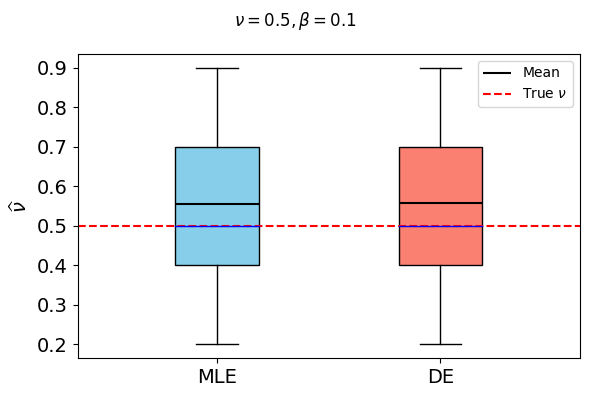

In [3]:
theta=torch.tensor([1,0.1],dtype=torch.float64)
length_scale=0.1
nu=0.5
beta=torch.tensor([-1,2,3,-2,1],dtype=torch.float64)
delta=torch.tensor(0.25,dtype=torch.float64)
alpha=1
J=10
scale=torch.tensor([1,math.sqrt(2*nu)])
f_values_MLE=np.zeros((100,8))
f_values_DE=np.zeros((100,8))

with open(f'expriements/decentralized/estimating_nu/r_range(25)_nu_{nu}.pkl', 'rb') as f:
    results_range_25=pickle.load(f)
for r  in range(25):
    for i in range(8):
        f_values_MLE[r,i]=results_range_25[8*r+i][1][3]
        f_values_DE[r,i]=results_range_25[8*r+i][0][3].detach().numpy().item()  
             
with open(f'expriements/decentralized/estimating_nu/r_range(25,60)_nu_{nu}.pkl', 'rb') as f:
    results_range_25_60=pickle.load(f)
for r  in range(25,60):
    for i in range(8):
        f_values_MLE[r,i]=results_range_25_60[8*(r-25)+i][1][3]
        f_values_DE[r,i]=results_range_25_60[8*(r-25)+i][0][3].detach().numpy().item()   
        
with open(f'expriements/decentralized/estimating_nu/r_range(60,100)_nu_{nu}.pkl', 'rb') as f:
    results_range_60_100=pickle.load(f)
for r  in range(60,100):
    for i in range(8):
        f_values_MLE[r,i]=results_range_60_100[8*(r-60)+i][1][3]
        f_values_DE[r,i]=results_range_60_100[8*(r-60)+i][0][3].detach().numpy().item()     


indexs=np.argmin(f_values_DE,axis=1)
nus=np.arange(0.2, 1, 0.1)
estiamted_nus_DE=np.zeros((100,))
for r in range(100):
    estiamted_nus_DE[r]=nus[indexs[r]]
estiamted_nus_DE

indexs=np.argmin(f_values_MLE,axis=1)
nus=np.arange(0.2, 1, 0.1)
estiamted_nus_MLE=np.zeros((100,))
for r in range(100):
    estiamted_nus_MLE[r]=nus[indexs[r]]
estiamted_nus_MLE

import numpy as np

plt.figure(figsize=(6, 4))
positions = [0, 0.8]
plt.suptitle(fr'$\nu={nu},\beta={0.1}$')

colors = ['skyblue', 'salmon']
box = plt.boxplot(
    [estiamted_nus_MLE, estiamted_nus_DE],
    labels=['MLE', 'DE'],
    patch_artist=True,
    medianprops={'color': 'blue'},
    positions=positions,
    widths=0.3
)

# Set color for each box
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Calculate means
means = [np.mean(estiamted_nus_MLE), np.mean(estiamted_nus_DE)]

# Plot means as horizontal lines
for pos, mean in zip(positions, means):
    plt.hlines(mean, pos - 0.15, pos + 0.15, colors='black', linestyles='-', linewidth=1.5, label='Mean' if pos == positions[0] else "")

# Plot the reference line for the true value
plt.axhline(y=nu, color='r', linestyle='--', label=r'True $\nu$')

# Set labels and ticks
plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel(r'$\widehat{\nu}$', fontsize=14)

# Add legend
plt.legend()

plt.tight_layout()
plt.savefig(f'expriements/decentralized/estimating_nu/boxplot_covpara_nu_{nu}_length_scale_{length_scale}.pdf', dpi=300)
plt.show()


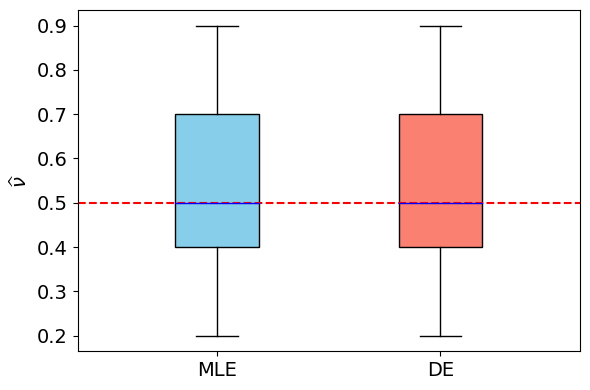

In [5]:
indexs=np.argmin(f_values_DE,axis=1)
nus=np.arange(0.2, 1, 0.1)
estiamted_nus_DE=np.zeros((100,))
for r in range(100):
    estiamted_nus_DE[r]=nus[indexs[r]]


indexs=np.argmin(f_values_MLE,axis=1)
nus=np.arange(0.2, 1, 0.1)
estiamted_nus_MLE=np.zeros((100,))
for r in range(100):
    estiamted_nus_MLE[r]=nus[indexs[r]]

plt.figure(figsize=(6, 4))
positions = [0,0.8]
#plt.suptitle(fr'$\nu={0.5},\beta={0.1}$')


colors = ['skyblue']+['salmon']
box=plt.boxplot([estiamted_nus_MLE] + [estiamted_nus_DE], labels=['MLE'] + [f'DE'],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
plt.yticks(fontsize=14)    
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

"""BufferError  
# Calculate means
means = [np.mean(estiamted_nus_MLE), np.mean(estiamted_nus_DE)]

# Plot means as horizontal lines
for pos, mean in zip(positions, means):
    plt.hlines(mean, pos - 0.15, pos + 0.15, colors='black', linestyles='-', linewidth=1.5, label='Mean' if pos == positions[0] else "")
"""

plt.axhline(y=nu, color='r', linestyle='--', label=r'True $\nu$')
#plt.title('Boxplot for alphas')
plt.ylabel(r'$\widehat{\nu}$',fontsize=14)


plt.tight_layout()
# Add legend
#plt.legend()
plt.savefig(f'expriements/decentralized/estimating_nu/boxplot_covpara_nu_{nu}_length_scale_{length_scale}_without_title.pdf', dpi=300)
plt.show()